In [3]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

from src.data_loader import load_air_passengers, train_test_split_time_series

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

In [4]:
df = load_air_passengers()
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
df.head()

Shape: (144, 1)
Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00


,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


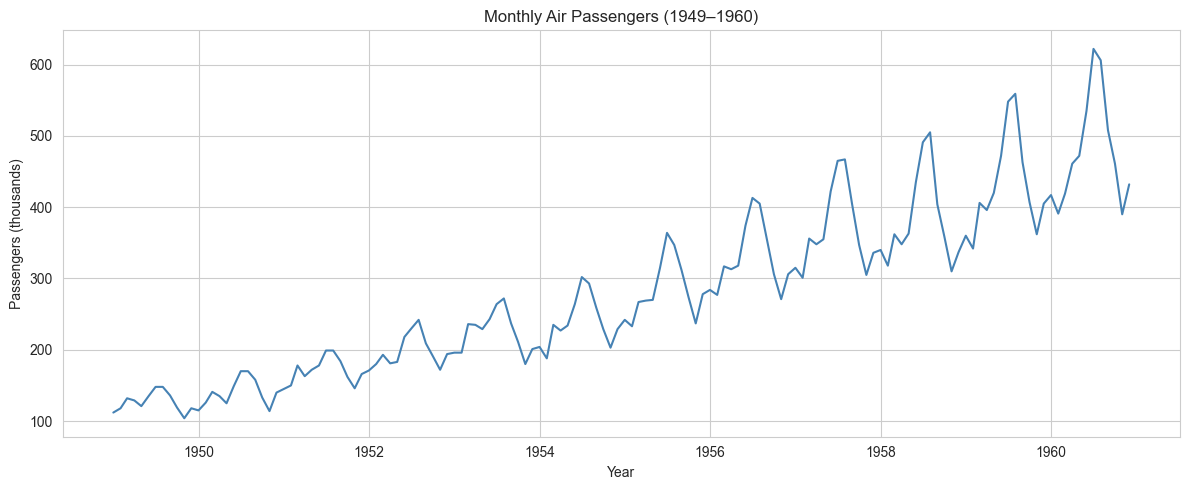

In [5]:
fig, ax = plt.subplots()
ax.plot(df.index, df['value'], color='steelblue', linewidth=1.5)
ax.set_title('Monthly Air Passengers (1949–1960)')
ax.set_xlabel('Year')
ax.set_ylabel('Passengers (thousands)')
plt.tight_layout()
plt.savefig('../results/figures/01_raw_series.png', dpi=150)
plt.show()

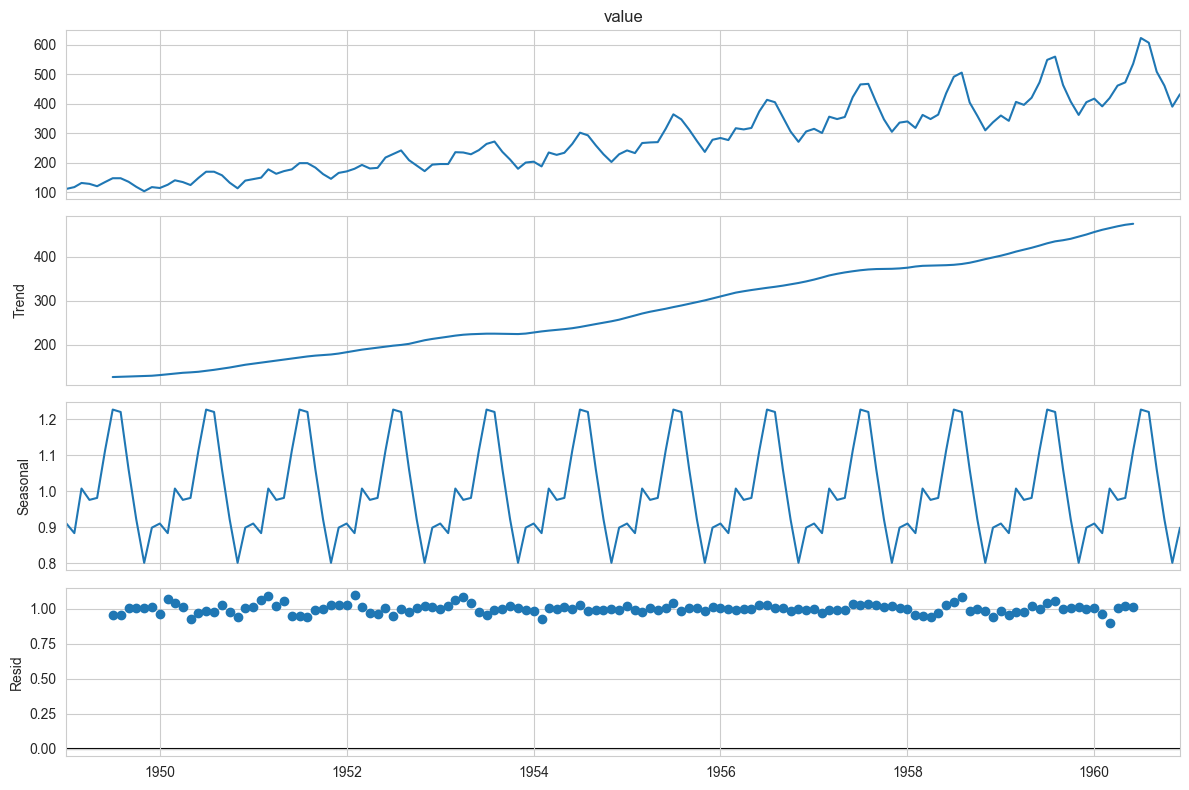

In [6]:
decomposition = seasonal_decompose(df['value'], model='multiplicative', period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig('../results/figures/02_decomposition.png', dpi=150)
plt.show()

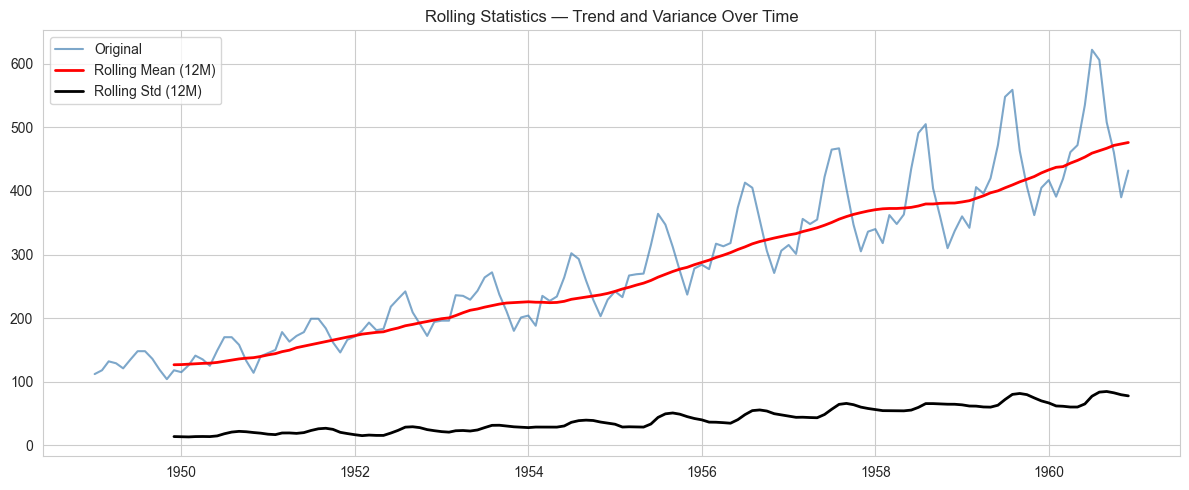

In [7]:
rolling_mean = df['value'].rolling(window=12).mean()
rolling_std = df['value'].rolling(window=12).std()

fig, ax = plt.subplots()
ax.plot(df['value'], label='Original', color='steelblue', alpha=0.7)
ax.plot(rolling_mean, label='Rolling Mean (12M)', color='red', linewidth=2)
ax.plot(rolling_std, label='Rolling Std (12M)', color='black', linewidth=2)
ax.set_title('Rolling Statistics — Trend and Variance Over Time')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/03_rolling_stats.png', dpi=150)
plt.show()

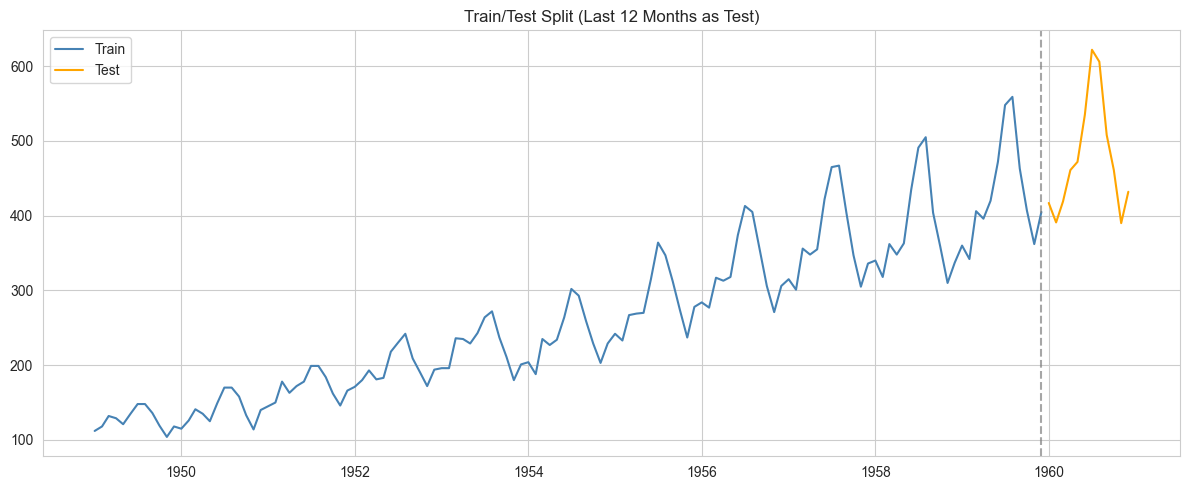

Train: 1949-01-01 00:00:00 to 1959-12-01 00:00:00 (132 samples)
Test:  1960-01-01 00:00:00 to 1960-12-01 00:00:00 (12 samples)


In [8]:
train, test = train_test_split_time_series(df, test_size=12)

fig, ax = plt.subplots()
ax.plot(train.index, train['value'], label='Train', color='steelblue')
ax.plot(test.index, test['value'], label='Test', color='orange')
ax.axvline(train.index[-1], color='gray', linestyle='--', alpha=0.7)
ax.set_title('Train/Test Split (Last 12 Months as Test)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/04_train_test_split.png', dpi=150)
plt.show()

print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} samples)")
print(f"Test:  {test.index.min()} to {test.index.max()} ({len(test)} samples)")


In [9]:
df.to_csv('../data/raw/air_passengers.csv')
train.to_csv('../data/processed/train.csv')
test.to_csv('../data/processed/test.csv')
print("Data saved.")

Data saved.
